# PDAN POE part 1

## Project Overview

### Project Title:
Medical Insurance Cost Analysis using Linear Regression

### Goal of the Project:
The goal of this analysis is to understand how different factors such as age, BMI, smoking status, and others affect medical insurance charges.

### Author:
[ST 10345096]

In [14]:
## Imports the libraries needed for data analysis, visualization, and modeling.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

These libraries are used for:
- pandas → handling data
- numpy → numerical operations
- matplotlib & seaborn → data visualization

## Data Overview

### The dataset is loaded into the notebook using pandas for linear regression analysis.

In [6]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset is loaded and previewed to understand its structure and variables.


In [7]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


This step checks:
- `.shape` shows number of rows and columns  
- `.info()` shows data types and missing values  
- `.describe()` gives statistical summary  

This helps understand what kind of data we are working with

## Data CLeaning
### The dataset is checked for missing values and duplicates.


In [8]:
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()

This step checks if there are:
- Missing values (empty data)
- Duplicate rows (repeated data)

Categorical variables such as sex, smoker status, and region are converted into numerical format.

This is necessary because machine learning models only work with numbers.

## Exploratory Data Analysis (EDA)

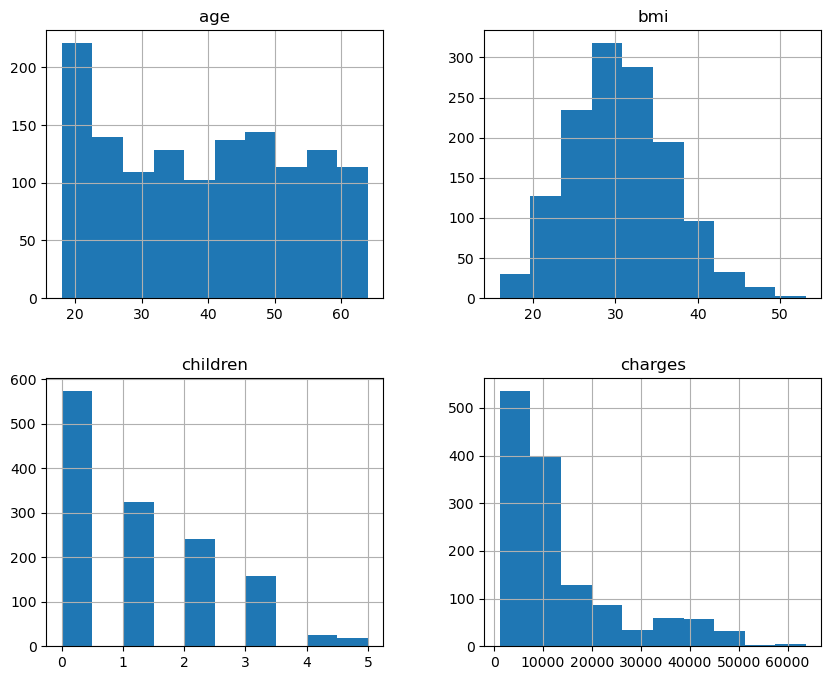

In [15]:
### Distribution
df.hist(figsize=(10,8))
plt.show()

Histograms show how values are distributed.

Charges are right-skewed, meaning a small number of individuals have very high medical costs.

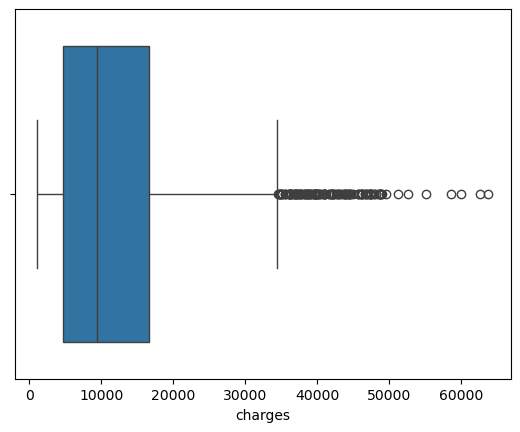

In [16]:
### Boxplot (Outliers)
sns.boxplot(x=df["charges"])
plt.show()

Boxplots help identify outliers.

Outliers are extreme values that can affect the model.  
In this dataset, high charges are considered outliers.

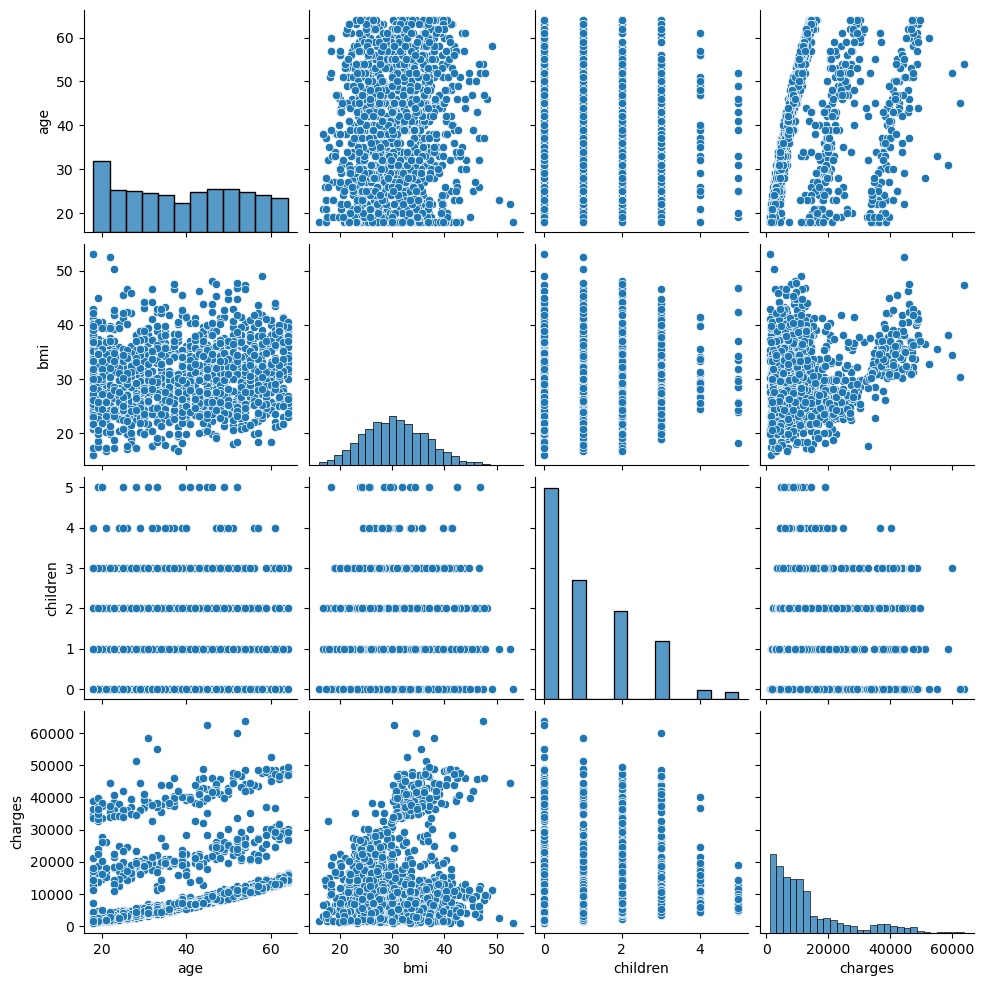

In [17]:
### Relationships
sns.pairplot(df)
plt.show()

Pairplots show relationships between variables.

- Positive trend = variables increase together  
- No pattern = weak relationship  

This helps decide which features are useful.

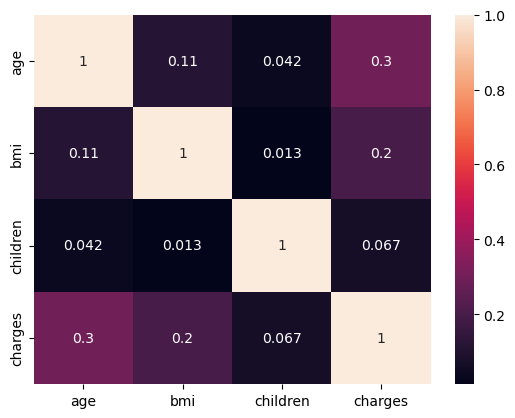

In [18]:
### Correlation Heatmap
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

Correlation values range from -1 to 1.

- Closer to 1 → strong positive relationship  
- Closer to 0 → weak relationship  

In [19]:
## Encode Categorical Variables
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Categorical variables (like smoker, sex, region) are converted into numbers.

This is required because machine learning models only work with numerical data.

## Feature Selection

In [20]:
corr = df_encoded.corr()
corr["charges"].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64

This shows which variables have the strongest relationship with charges.

Features with stronger relationships are more important for prediction.

## Training and testing

In [22]:
### Define X and y
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

- X = input features  
- y = target variable (charges)  

The model will learn how X affects y.

In [23]:
### Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is split into:
- Training data (80%) → used to train the model  
- Testing data (20%) → used to evaluate performance  

This ensures the model generalizes well.

In [24]:
### Train Linear Regression ModeL
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The model learns the relationship between features and charges.

It fits a line using the equation:
y = mx + c

In [25]:
### Make Predictions
y_pred = model.predict(X_test)

The model predicts charges using unseen test data.

In [30]:
### Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))

           Actual     Predicted
900    8688.85885   8143.693884
1064   5708.86700   5737.115683
1256  11436.73815  14369.314876
298   38746.35510  31745.513636
237    4463.20510   8962.386657
481    9304.70190  13149.722353
240   38511.62830  30446.760679
277    2150.46900   1453.288813
415    7345.72660  10633.018402
707   10264.44210  11318.943794


y_pred contains predicted insurance charges.
Comparing actual vs predicted values helps assess model accuracy.

## Evaluate Model


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

MAE: 4177.045561036319
RMSE: 5956.342894363587
R² Score: 0.8069287081198012


MAE (Mean Absolute Error): Average magnitude of errors in predictions.

RMSE (Root Mean Squared Error): Gives higher weight to large errors.

R² Score: Proportion of variance in charges explained by the model (closer to 1 is better).

## Interpret Coefficients

In [28]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coeff_df

,Coefficient
age,248.210720
bmi,318.701441
children,533.009989
sex_male,-101.542054
smoker_yes,23077.764593
region_northwest,-391.761455
region_southeast,-838.919616
region_southwest,-659.139752


Coefficients show how each feature affects charges.

- Positive value → increases charges  
- Negative value → decreases charges  

Example:
Smoking has a strong positive impact on charges.

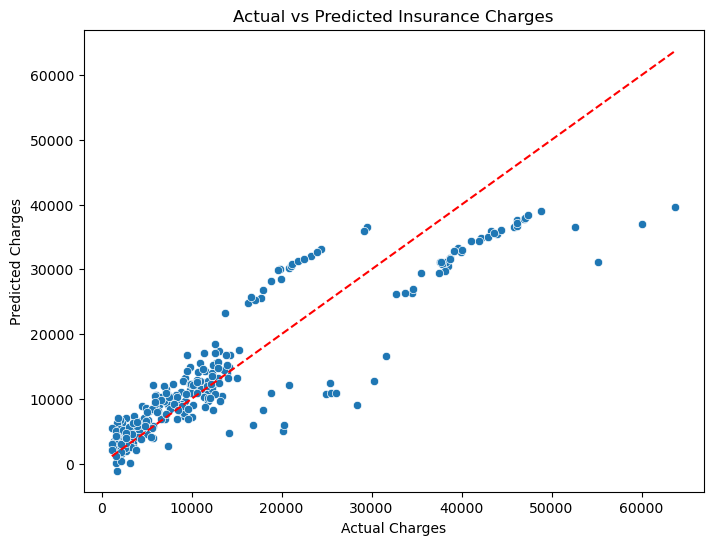

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

Points close to the red dashed line indicate accurate predictions.

Most points cluster near the line, suggesting the model predicts well for the majority of cases.

Outliers exist where extremely high charges occur, mainly for older smokers.

## Conclusion

The analysis showed that smoking status, BMI, and age are key factors influencing medical insurance charges.

The Linear Regression model was able to capture relationships between variables and make predictions with reasonable accuracy.

However, the presence of outliers and skewed data may affect performance, and further improvements could be made more.